<a href="https://colab.research.google.com/github/Uzma2147/PulseIQ/blob/main/PulseIQ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
df.shape
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df["customerID"].duplicated().sum()

np.int64(0)

In [ ]:
#Univariate Analysis
df["tenure"].describe()

,tenure
count,7043.000000
mean,32.371149
std,24.559481
min,0.000000
25%,9.000000
50%,29.000000
75%,55.000000
max,72.000000


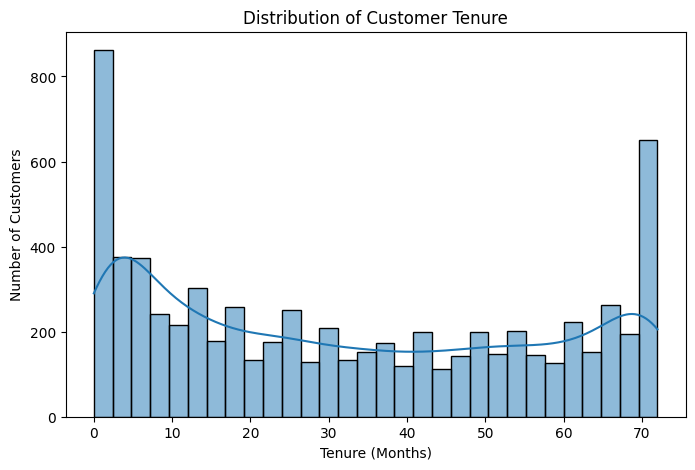

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="tenure", bins=30, kde=True)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

Most customers are concentrated toward the lower and higher ends of tenure, rather than evenly across all months.
There are noticeable spikes, especially around 1 month and 72 months.
The distribution is not perfectly symmetric; it has a somewhat irregular shape with clear spikes at certain tenure values.

In [ ]:
#Monthly Charge
df["MonthlyCharges"].describe()

,MonthlyCharges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


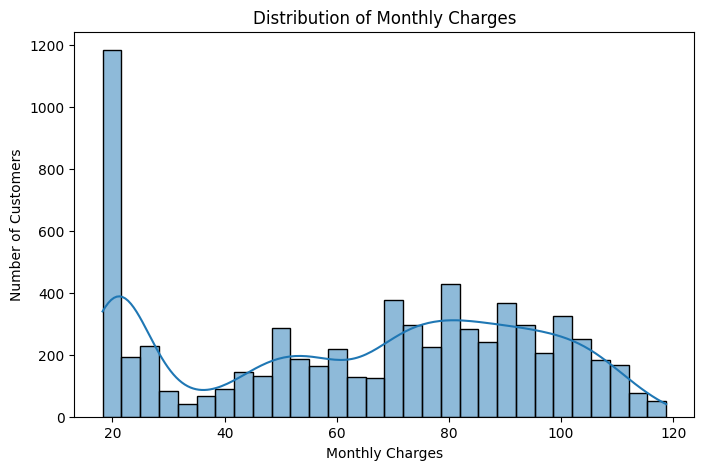

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="MonthlyCharges", bins=30, kde=True)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

Where are most customers paying?
Most customers are paying around $20–$100 per month, with a large concentration roughly between $50 and $90.
Is the distribution skewed?
The distribution is not perfectly symmetric. It has noticeable variation across the range, with some concentration toward the higher monthly charges.
Are there unusual spikes?
Yes. There are noticeable spikes at certain charge levels rather than a completely smooth distribution. This is likely because telecom plans and service combinations create repeated monthly prices.
Are there very high or very low values?
Yes. Monthly charges range from about $18.25 to $118.75. The very low values are around the basic-service customers, while the highest values represent customers with multiple or premium services.

In [ ]:
#For the same DataFrame, the last two must give the same dtyp
print(df.shape)

print(df["TotalCharges"].dtype)

print(df.dtypes["TotalCharges"])

(7043, 21)
object
object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
print(type(df))
print(id(df))

<class 'pandas.core.frame.DataFrame'>
135735346791376


In [ ]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [ ]:
print(df["TotalCharges"].dtype)

float64


In [ ]:
#Check missing values
df["TotalCharges"].isnull().sum()

np.int64(11)

In [ ]:
#Now let's find those 11 customers
df[df["TotalCharges"].isnull()][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [ ]:
df["TotalCharges"].describe()

,TotalCharges
count,7032.000000
mean,2283.300441
std,2266.771362
min,18.800000
25%,401.450000
50%,1397.475000
75%,3794.737500
max,8684.800000


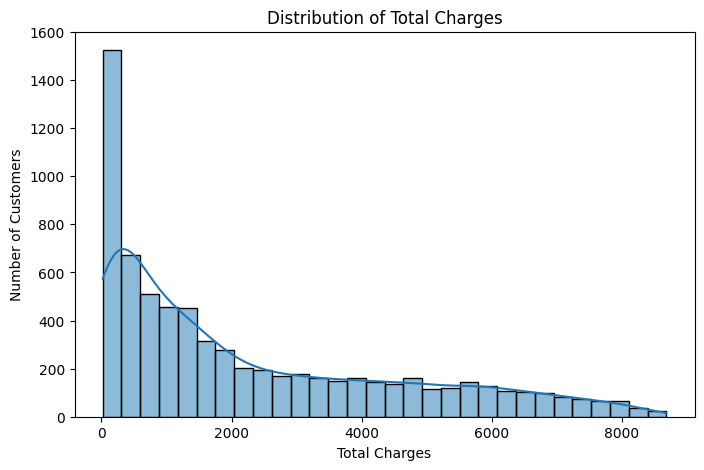

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="TotalCharges", bins=30, kde=True)

plt.title("Distribution of Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
#Categorical Variables
categorical_columns = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
    "Churn"
]
#Show every column in categories
for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts())


--- gender ---
gender
Male      3555
Female    3488
Name: count, dtype: int64

--- SeniorCitizen ---
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

--- Partner ---
Partner
No     3641
Yes    3402
Name: count, dtype: int64

--- Dependents ---
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

--- PhoneService ---
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

--- MultipleLines ---
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

--- InternetService ---
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

--- OnlineSecurity ---
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

--- OnlineBackup ---
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

--- DeviceProtection ---
DeviceProtec

In [ ]:
#Bivariate Analysis


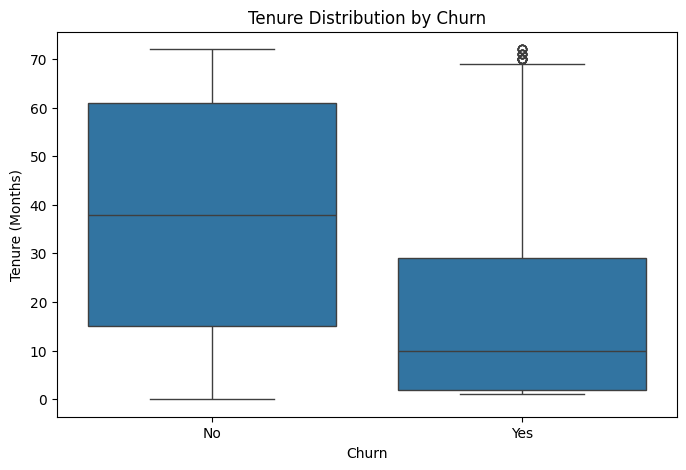

In [ ]:
#Tenure Vs Churn
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

Churn
No  → customers who stayed
Yes → customers who churned
Do customers who churn have different tenure than customers who stay?
And the answer is clearly yes.
The median is around:
38 months
So half of the customers who stayed have tenure below about 38 months, and half have tenure above it.
The median is around:
10 months
That's a huge difference.
Customers who churned generally had a much shorter relationship with the company.

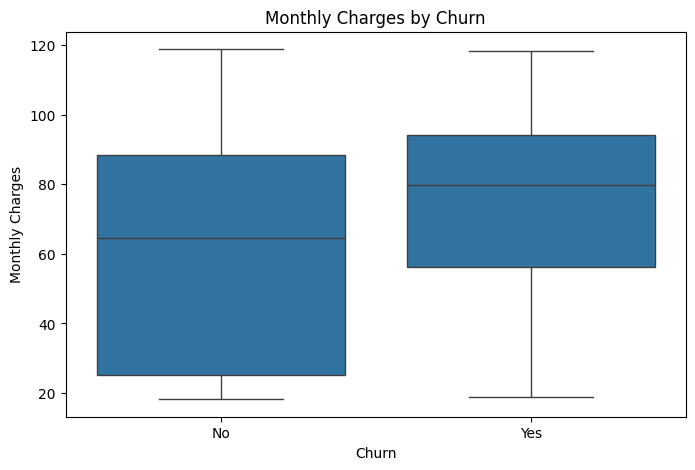

In [ ]:
#MonthlyCharges vs Churn
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

**Median:**
In this Telco dataset, the median monthly charge for churned customers is higher than for customers who stayed.
So, generally:
Customers who churn tend to pay more per month than customers who stay.

**Spread**

The box represents the middle 50% of customers.

You'll notice that the monthly charges for churned customers are generally distributed toward the higher-charge range.

This means churn isn't limited to customers paying the cheapest plans.

In fact, many customers who leave are paying relatively high monthly charges


Churned customers have higher monthly charges than retained customers, with a median of approximately $80 compared with $65 for retained customers. Neither group shows visible outliers, and the values near $118–119 are within the normal range. This supports our hypothesis that higher monthly charges are associated with higher churn.

In [ ]:
#Contract vs Churn
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


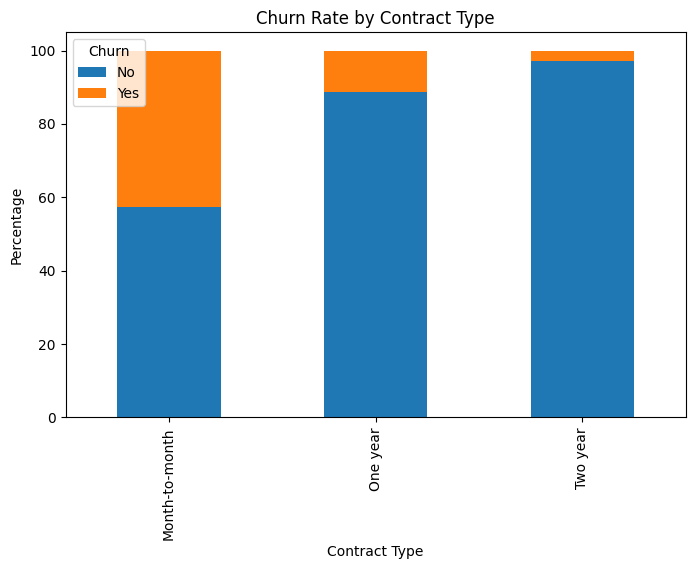

In [ ]:
contract_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage")
plt.legend(title="Churn")

plt.show()

Customers with month-to-month contracts are more likely to churn than customers with longer contracts

In [ ]:
#InternetService vs Churn
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


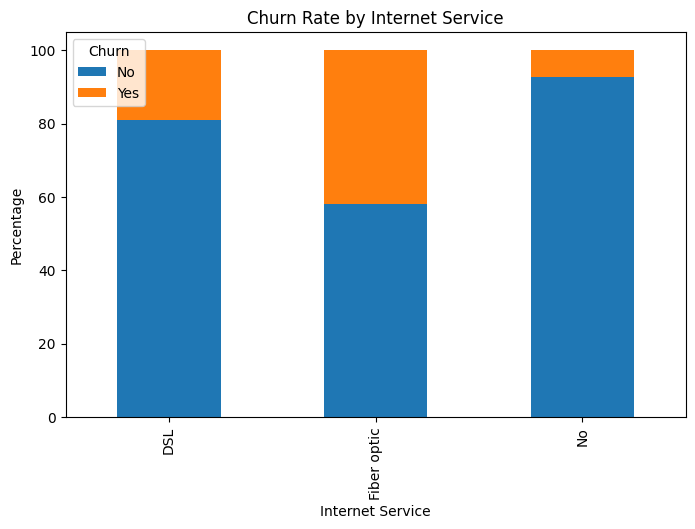

In [ ]:
internet_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Percentage")
plt.legend(title="Churn")

plt.show()

Customers with fiber-optic internet are more likely to churn than customers with other internet service

In [ ]:
#PaymentMethod vs Churn
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


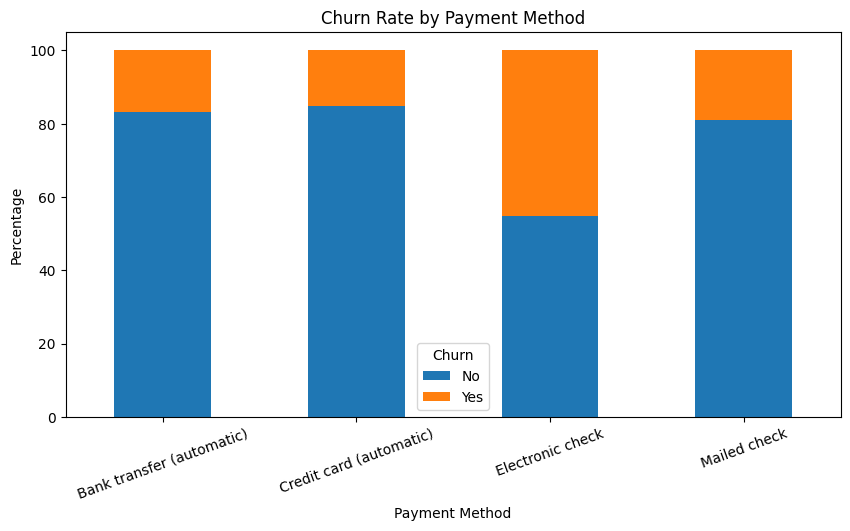

In [ ]:
payment_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Percentage")
plt.xticks(rotation=20)
plt.legend(title="Churn")

plt.show()

In [ ]:
#SeniorCitizen vs Churn
senior_churn = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

senior_churn

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


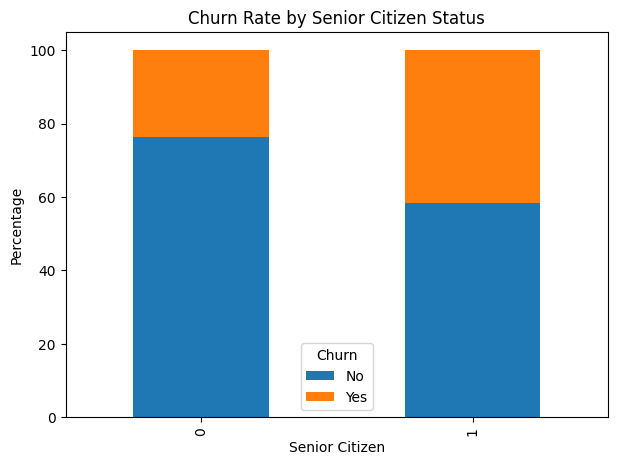

In [ ]:
senior_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(7, 5)
)

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Percentage")
plt.legend(title="Churn")

plt.show()

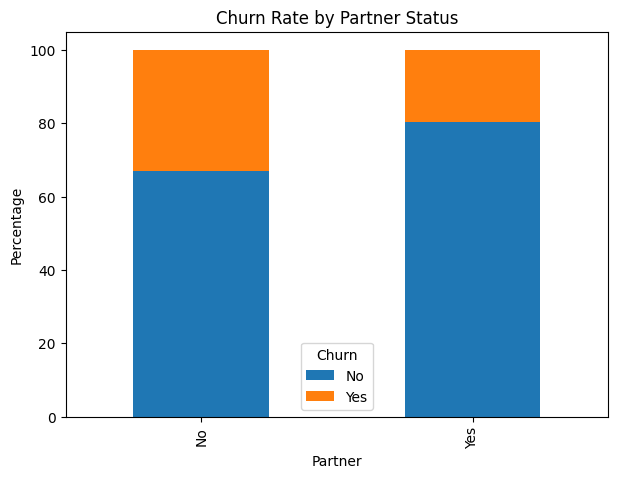

In [ ]:
#Partner vs Churn
partner_churn = pd.crosstab(
    df["Partner"],
    df["Churn"],
    normalize="index"
) * 100

partner_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(7, 5)
)

plt.title("Churn Rate by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Percentage")
plt.legend(title="Churn")

plt.show()

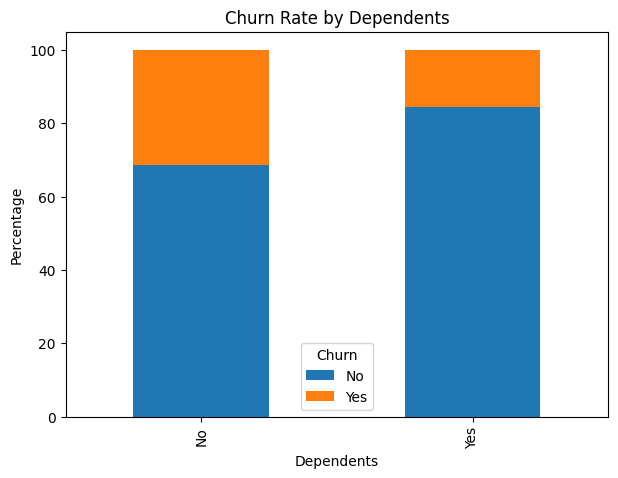

In [ ]:
#Dependents vs Churn
dependents_churn = pd.crosstab(
    df["Dependents"],
    df["Churn"],
    normalize="index"
) * 100

dependents_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(7, 5)
)

plt.title("Churn Rate by Dependents")
plt.xlabel("Dependents")
plt.ylabel("Percentage")
plt.legend(title="Churn")

plt.show()

In [ ]:
#Correlation Analysis
numeric_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

correlation = df[numeric_columns].corr()

correlation

,tenure,MonthlyCharges,TotalCharges
tenure,1.00000,0.247900,0.825880
MonthlyCharges,0.24790,1.000000,0.651065
TotalCharges,0.82588,0.651065,1.000000


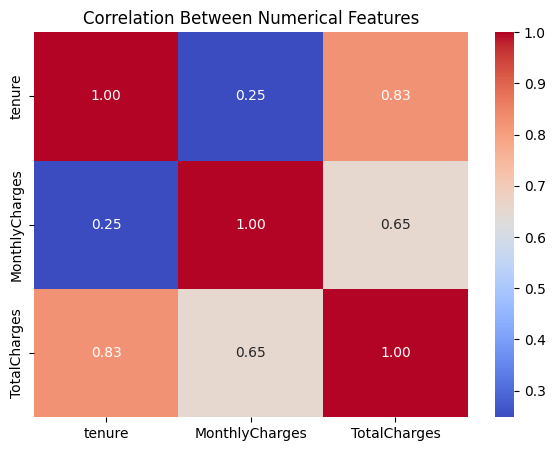

In [ ]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Numerical Features")

plt.show()

In [ ]:
from scipy.stats import chi2_contingency, ttest_ind

In [ ]:
#Statistical Validation'
#Using Chi-Square Testing of independence
#P-value Result

In [ ]:
#Contract vs Churn
#Create Contingency Table
contract_table = pd.crosstab(
    df["Contract"],
    df["Churn"]
)

contract_table

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [ ]:
chi2, p, dof, expected = chi2_contingency(contract_table)

print("Chi-square statistic:", chi2)
print("p-value:", p)

Chi-square statistic: 1184.5965720837926
p-value: 5.863038300673391e-258


What does this tell us?

Our null hypothesis was:

H₀: Contract type and Churn are independent.

In simple language:

"Contract type has nothing to do with whether a customer churns."

Your result gives extremely strong evidence against that assumption.

So we reject the null hypothesis.

Our conclusion is:

There is a statistically significant association between contract type and customer churn.

In [ ]:
#InternetService vs Churn
internet_table = pd.crosstab(
    df["InternetService"],
    df["Churn"]
)

internet_table

Churn,No,Yes
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


In [ ]:
chi2, p, dof, expected = chi2_contingency(internet_table)

print("Chi-square statistic:", chi2)
print("p-value:", p)


Chi-square statistic: 732.309589667794
p-value: 9.571788222840544e-160


Internet service type and churn are statistically significantly associated.

In [ ]:
#TechSupport vs Churn
techsupport_table = pd.crosstab(
    df["TechSupport"],
    df["Churn"]
)

techsupport_table

Churn,No,Yes
TechSupport,,
No,2027,1446
No internet service,1413,113
Yes,1734,310


In [ ]:
chi2, p, dof, expected = chi2_contingency(techsupport_table)

print("Chi-square statistic:", chi2)
print("p-value:", p)

Chi-square statistic: 828.1970684587394
p-value: 1.4430840279998987e-180


In [ ]:
#PaymentMethod vs Churn
payment_table = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"]
)

payment_table


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


In [ ]:
chi2, p, dof, expected = chi2_contingency(payment_table)

print("Chi-square statistic:", chi2)
print("p-value:", p)

Chi-square statistic: 648.1423274814
p-value: 3.6823546520097993e-140


In [ ]:
#Part B — Numeric Variables

In [ ]:
#tenure vs churn
tenure_churned = df[df["Churn"] == "Yes"]["tenure"]

tenure_retained = df[df["Churn"] == "No"]["tenure"]

print("Mean tenure - Churned:", tenure_churned.mean())
print("Mean tenure - Retained:", tenure_retained.mean())

Mean tenure - Churned: 17.979133226324237
Mean tenure - Retained: 37.56996521066873


In [ ]:
t_stat, p = ttest_ind(
    tenure_churned,
    tenure_retained,
    equal_var=False
)

print("t-statistic:", t_stat)
print("p-value:", p)

t-statistic: -34.823818696312976
p-value: 1.1954945472607151e-232


The difference in average tenure between churned and retained customers is statistically significant (p < 0.001). Churned customers have substantially lower average tenure, supporting the hypothesis that newer customers are at higher risk of churn.

In [ ]:
#MonthlyCharges vs Churn
charges_churned = df[df["Churn"] == "Yes"]["MonthlyCharges"]

charges_retained = df[df["Churn"] == "No"]["MonthlyCharges"]

print("Mean MonthlyCharges - Churned:", charges_churned.mean())
print("Mean MonthlyCharges - Retained:", charges_retained.mean())

Mean MonthlyCharges - Churned: 74.44133226324237
Mean MonthlyCharges - Retained: 61.26512369540008


In [ ]:
t_stat, p = ttest_ind(
    charges_churned,
    charges_retained,
    equal_var=False
)

print("t-statistic:", t_stat)
print("p-value:", p)

t-statistic: 18.407526676414673
p-value: 8.59244933154705e-73


The difference in average monthly charges between churned and retained customers is statistically significant (p < 0.001). Churned customers have higher average monthly charges, supporting the hypothesis that higher monthly charges are associated with increased churn.

In [ ]:
#Corelation
numeric_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

correlation = df[numeric_columns].corr()

correlation

,tenure,MonthlyCharges,TotalCharges
tenure,1.00000,0.247900,0.825880
MonthlyCharges,0.24790,1.000000,0.651065
TotalCharges,0.82588,0.651065,1.000000


+1 → strong positive relationship
0 → little/no linear relationship
-1 → strong negative relationship

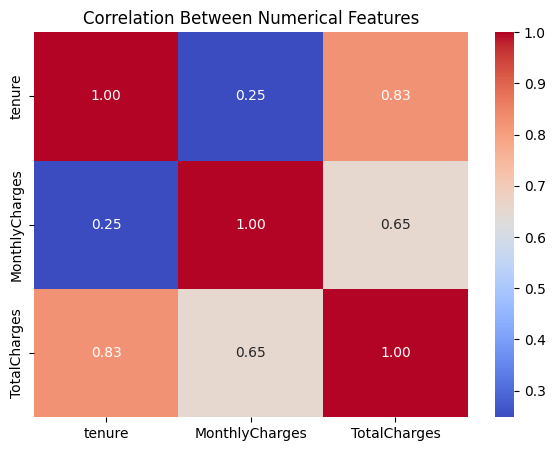

In [ ]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Numerical Features")

plt.show()

In [ ]:
#Preprocessing & Feature Engineering
#Make a working copy
#Don't destroy your original EDA dataframe.
df_model = df.copy()

Why?

We don't want to accidentally change our original dataset.

In [ ]:
#. Remove TotalCharges and CustomerID
df_model = df_model.drop(columns=["TotalCharges"])

df_model = df_model.drop(columns=["customerID"])

We will drop TotalCharges because of its strong correlation with Tenure and because it is largely derived from tenure and monthly charges

In [ ]:
print(df_model.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'Churn']


In [ ]:
#Churn is 0/1
if df_model["Churn"].dtype == "object":
    df_model["Churn"] = df_model["Churn"].map({
        "No": 0,
        "Yes": 1
    })
print(df_model["Churn"].value_counts(dropna=False))

Churn
0    5174
1    1869
Name: count, dtype: int64


This means:

If Churn is still "Yes"/"No" → convert it.
If Churn is already 0/1 → leave it alone.

In [ ]:
##Feature Engineering,Create ServiceCount
service_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df_model["ServiceCount"] = (
    df_model[service_columns]
    .eq("Yes")
    .sum(axis=1)
)

print("ServiceCount" in df_model.columns)

True


In [ ]:
df_model["ServiceCount"].value_counts().sort_index()

,count
ServiceCount,
0,2219
1,966
2,1033
3,1118
4,852
5,571
6,284


In [ ]:
#Create TenureBucket
df_model["TenureBucket"] = pd.cut(
    df_model["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12", "13-24", "25-48", "49+"]
)
df_model["TenureBucket"].value_counts().sort_index()

,count
TenureBucket,
0-12,2186
13-24,1024
25-48,1594
49+,2239


Why create this?

Our EDA showed that tenure is strongly related to churn.

The relationship might not be perfectly linear, so these groups allow the model to distinguish different customer lifecycle stages.

In [ ]:
#Check our data before modeling
print("Shape:", df_model.shape)

print("\nMissing values:")
print(df_model.isnull().sum())

print("\nChurn:")
print(df_model["Churn"].value_counts(dropna=False))

print("\nServiceCount exists:",
      "ServiceCount" in df_model.columns)

print("TenureBucket exists:",
      "TenureBucket" in df_model.columns)

Shape: (7043, 21)

Missing values:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
Churn               0
ServiceCount        0
TenureBucket        0
dtype: int64

Churn:
Churn
0    5174
1    1869
Name: count, dtype: int64

ServiceCount exists: True
TenureBucket exists: True


In [ ]:
#Separate Features X and Target y
#Now we tell the model what it can use and what it needs to predict
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]


In [ ]:
#Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

Why stratify=y?

Churn is imbalanced:

Stayed   → 5174
Churned  → 1869

stratify=y keeps approximately the same churn ratio in both training and testing data.

In [ ]:
print("Training:")
print(y_train.value_counts(normalize=True))

print("\nTesting:")
print(y_test.value_counts(normalize=True))

Training:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Testing:
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [ ]:
#Define numerical features
numeric_features = [
    "tenure",
    "MonthlyCharges",
    "ServiceCount",
    "SeniorCitizen"
]
#Define categorical features
categorical_features = [
    col for col in X_train.columns
    if col not in numeric_features
]
print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['tenure', 'MonthlyCharges', 'ServiceCount', 'SeniorCitizen']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureBucket']


In [ ]:
#Final safety check — no missing features
missing_features = [
    col for col in numeric_features + categorical_features
    if col not in X_train.columns
]

print("Missing features:", missing_features)

Missing features: []


In [ ]:
##Create the preprocessing pipeline
#we'll tell Python how to process each type of feature.
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

A preprocessing pipeline is a structured, automated sequence of steps used to clean, transform, and organize raw data so that it is ready for machine learning models or data analysis. It acts as a factory assembly line, taking in messy, real-world data at one end and outputting standardized, high-quality information at the other

In [ ]:
#Fit preprocessing on training data
X_train_processed = preprocessor.fit_transform(X_train)

#Transform test data
X_test_processed = preprocessor.transform(X_test)

fit_transform() means:
First:fit → learn the preprocessing rules
Then:
transform → apply those rules
The important point is that we learn the rules only from training data

In [ ]:
print("Original X_train:", X_train.shape)
print("Processed X_train:", X_train_processed.shape)

print("\nOriginal X_test:", X_test.shape)
print("Processed X_test:", X_test_processed.shape)

Original X_train: (5634, 20)
Processed X_train: (5634, 33)

Original X_test: (1409, 20)
Processed X_test: (1409, 33)


Why did the number of columns increase?
Because categorical variables were converted into numerical columns using One-Hot Encoding
One-hot encoding is a data preprocessing technique used in machine learning to convert categorical text or label data into binary numerical values (0 or 1)

In [ ]:
##Baseline Model: Logistic Regression
#Predict whether a customer will churn (1) or stay (0) based on their customer information.

In [ ]:
#Train the Logistic Regression model
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

class_weight="balanced"

Handles our class imbalance.

max_iter=1000

Gives the algorithm enough iterations to find a good solution.

random_state=42

Makes the result reproducibl

In [ ]:
#Train the model
logistic_model.fit(
    X_train_processed,
    y_train
)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

Training features
       +
Training Churn labels
       ↓
Learn patterns

In [ ]:
#Make predictions
#Now we'll use the unseen test data.
y_pred = logistic_model.predict(X_test_processed)


In [ ]:
y_prob = logistic_model.predict_proba(X_test_processed)[:, 1]

ROC-AUC measures how well our model can distinguish churners from customers who stay.
Can the model generally give higher churn probabilities to actual churners than to customers who stay?

In [ ]:
##Confusion Matrix

#Now we need to understand what the model got right and wrong.
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[737 298]
 [ 78 296]]


In [ ]:
#Calculate Precision, Recall and F1
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Stayed", "Churned"]
))

              precision    recall  f1-score   support

      Stayed       0.90      0.71      0.80      1035
     Churned       0.50      0.79      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.73      0.75      1409



In [ ]:
#ROC-AUC
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8414141414141414


In [ ]:
##Step 6
#Train Random Forest
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_model.fit(
    X_train_processed,
    y_train
)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [ ]:
#Evaluate Model
rf_pred = rf_model.predict(X_test_processed)

rf_prob = rf_model.predict_proba(
    X_test_processed
)[:, 1]

In [ ]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix
)

print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nRandom Forest Classification Report:")
print(
    classification_report(
        y_test,
        rf_pred,
        target_names=["Stayed", "Churned"]
    )
)

rf_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest ROC-AUC:", rf_auc)

Random Forest Confusion Matrix:
[[919 116]
 [197 177]]

Random Forest Classification Report:
              precision    recall  f1-score   support

      Stayed       0.82      0.89      0.85      1035
     Churned       0.60      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409

Random Forest ROC-AUC: 0.8174287633366918


In [ ]:
#Train XGBoost
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier
#Calculate the imbalance ratio:
scale_pos_weight = (
    y_train.value_counts()[0] /
    y_train.value_counts()[1]
)

print("Scale Pos Weight:", scale_pos_weight)

Scale Pos Weight: 2.768561872909699


In [ ]:
#Create Model
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)
#Train
xgb_model.fit(
    X_train_processed,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
xgb_pred = xgb_model.predict(X_test_processed)

xgb_prob = xgb_model.predict_proba(
    X_test_processed
)[:, 1]

In [ ]:
#Evaluate
print("XGBoost Confusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))

print("\nXGBoost Classification Report:")
print(
    classification_report(
        y_test,
        xgb_pred,
        target_names=["Stayed", "Churned"]
    )
)

xgb_auc = roc_auc_score(
    y_test,
    xgb_prob
)

print("XGBoost ROC-AUC:", xgb_auc)

XGBoost Confusion Matrix:
[[768 267]
 [ 82 292]]

XGBoost Classification Report:
              precision    recall  f1-score   support

      Stayed       0.90      0.74      0.81      1035
     Churned       0.52      0.78      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

XGBoost ROC-AUC: 0.8377005347593582


In [ ]:
#Now we compare all three models
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

results = []

# Logistic Regression
results.append({
    "Model": "Logistic Regression",
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
})

# Random Forest
results.append({
    "Model": "Random Forest",
    "Precision": precision_score(y_test, rf_pred),
    "Recall": recall_score(y_test, rf_pred),
    "F1": f1_score(y_test, rf_pred),
    "ROC-AUC": roc_auc_score(y_test, rf_prob)
})

# XGBoost
results.append({
    "Model": "XGBoost",
    "Precision": precision_score(y_test, xgb_pred),
    "Recall": recall_score(y_test, xgb_pred),
    "F1": f1_score(y_test, xgb_pred),
    "ROC-AUC": roc_auc_score(y_test, xgb_prob)
})

results_df = pd.DataFrame(results)

results_df

,Model,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.498316,0.791444,0.611570,0.841414
1,Random Forest,0.604096,0.473262,0.530735,0.817429
2,XGBoost,0.522361,0.780749,0.625938,0.837701


In [ ]:
#Random Forest tuning
from sklearn.model_selection import RandomizedSearchCV

# 1. Create parameter grid
rf_params = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_leaf": [1, 2, 4, 8]
}
# 2. Create search
rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=rf_params,
    n_iter=15,
    scoring="recall",
    cv=5,
    random_state=42,
    n_jobs=-1
)


In [ ]:

# 3. FIT / RUN THE SEARCH
rf_search.fit(X_train_processed, y_train)

# 4. Get the winner
print("Best Random Forest parameters:")
print(rf_search.best_params_)

print("\nBest CV Recall:")
print(rf_search.best_score_)

Best Random Forest parameters:
{'n_estimators': 100, 'min_samples_leaf': 8, 'max_depth': 5}

Best CV Recall:
0.8046822742474916


In [ ]:
#XGBoost tuning
xgb_params = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [2, 3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1]
}
xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42
    ),
    param_distributions=xgb_params,
    n_iter=15,
    scoring="recall",
    cv=5,
    random_state=42,
    n_jobs=-1
)

In [ ]:
xgb_search.fit(
    X_train_processed,
    y_train
)

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_const...
                                           max_delta_step=None, max_depth=None,
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [2, 3, 4, 5, 6],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='recall')

In [ ]:
print("Best XGBoost parameters:")
print(xgb_search.best_params_)

print("Best CV Recall:")
print(xgb_search.best_score_)

Best XGBoost parameters:
{'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01}
Best CV Recall:
0.8214046822742475


In [ ]:
#How do we check overfitting
rf_train_pred = rf_model.predict(X_train_processed)
rf_test_pred = rf_model.predict(X_test_processed)

print(
    "Random Forest Train Recall:",
    recall_score(y_train, rf_train_pred)
)

print(
    "Random Forest Test Recall:",
    recall_score(y_test, rf_test_pred)
)

Random Forest Train Recall: 0.9986622073578595
Random Forest Test Recall: 0.4732620320855615


In [ ]:
xgb_train_pred = xgb_model.predict(X_train_processed)
xgb_test_pred = xgb_model.predict(X_test_processed)

print(
    "XGBoost Train Recall:",
    recall_score(y_train, xgb_train_pred)
)

print(
    "XGBoost Test Recall:",
    recall_score(y_test, xgb_test_pred)
)

XGBoost Train Recall: 0.8782608695652174
XGBoost Test Recall: 0.7807486631016043


Random Forest has a huge gap:

98 - 72 = 26 percentage points

That's a warning sign.

XGBoost has:

91 - 78 = 13 percentage points

That's better

In [ ]:
print(type(xgb_model))

<class 'xgboost.sklearn.XGBClassifier'>


In [ ]:
#XGBoost Interpretation
##Part A — XGBoost feature importance
# Step 7A — XGBoost Feature Importance

import pandas as pd
import matplotlib.pyplot as plt

# Get feature names from the preprocessing pipeline
feature_names = preprocessor.get_feature_names_out()

# Get importance scores from the XGBoost model
importance = xgb_model.feature_importances_

# Create a DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Sort from most important to least important
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Display top 15 features
feature_importance_df.head(15)

,Feature,Importance
25,categorical__Contract_Two year,0.354029
24,categorical__Contract_One year,0.188420
10,categorical__InternetService_Fiber optic,0.147733
11,categorical__InternetService_No,0.069500
23,categorical__StreamingMovies_Yes,0.036714
28,categorical__PaymentMethod_Electronic check,0.025347
13,categorical__OnlineSecurity_Yes,0.017584
0,numeric__tenure,0.017471
26,categorical__PaperlessBilling_Yes,0.012711
21,categorical__StreamingTV_Yes,0.011868


The higher the importance, the more the feature contributed to the model's decisions in the way XGBoost's built-in importance measure defines it.

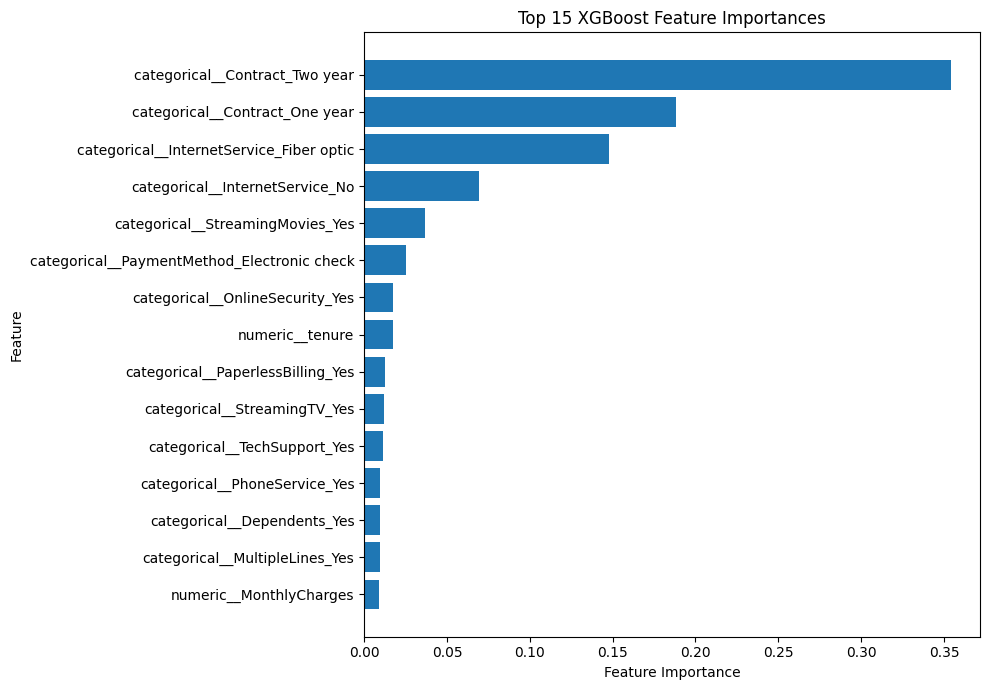

In [ ]:
#Step 7B — Plot the top 15
# Plot top 15 important features

top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Feature Importances")

plt.tight_layout()
plt.show()

You might think:

"Two-year customers usually churn less, so why is Contract_Two year the most important feature?"

This is a very important distinction:
XGBoost frequently finds this feature useful when making its decisions.

The feature could actually be pushing predictions away from churn.

That's exactly why we need SHAP.

In [ ]:
##Step 7B — SHAP
!pip install shap

In [ ]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# Create SHAP explainer for our XGBoost model
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for the test data
shap_values = explainer.shap_values(X_test_processed)

print("SHAP values shape:", shap_values.shape)
print("Test data shape:", X_test_processed.shape)

SHAP values shape: (1409, 33)
Test data shape: (1409, 33)


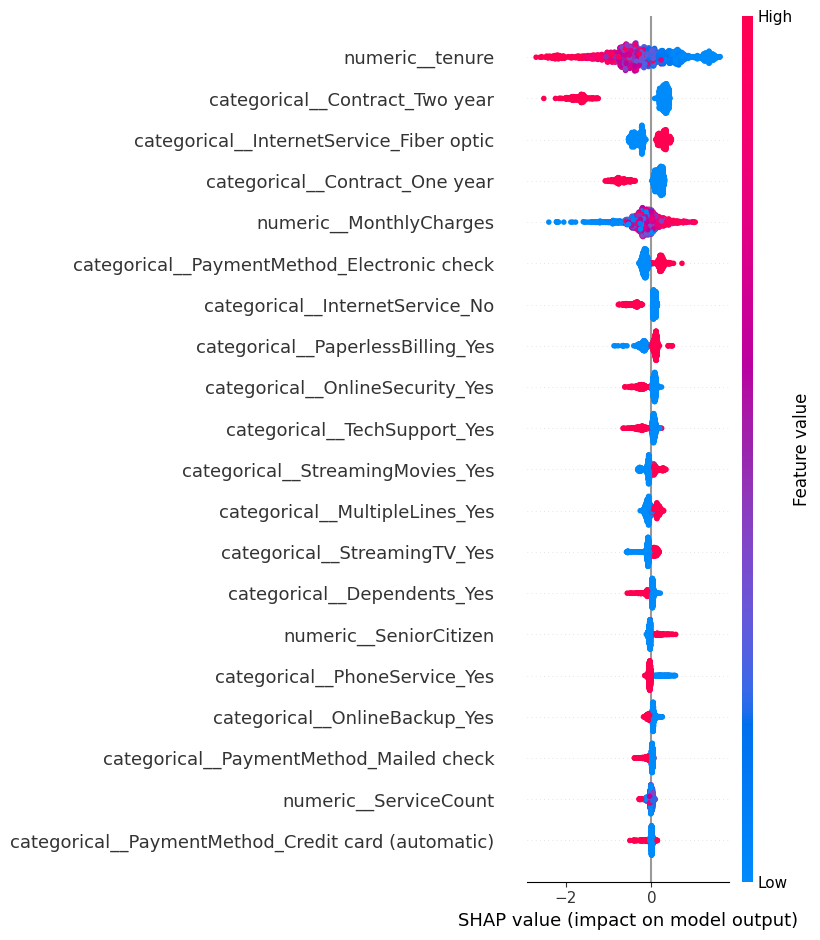

In [ ]:

# SHAP Summary Plot
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names
)

High tenure 🔴  ← mostly toward the left
Low tenure  🔵  → mostly toward the right
Customers with lower tenure tend to be pushed toward churn, while customers with higher tenure tend to be pushed away from churn

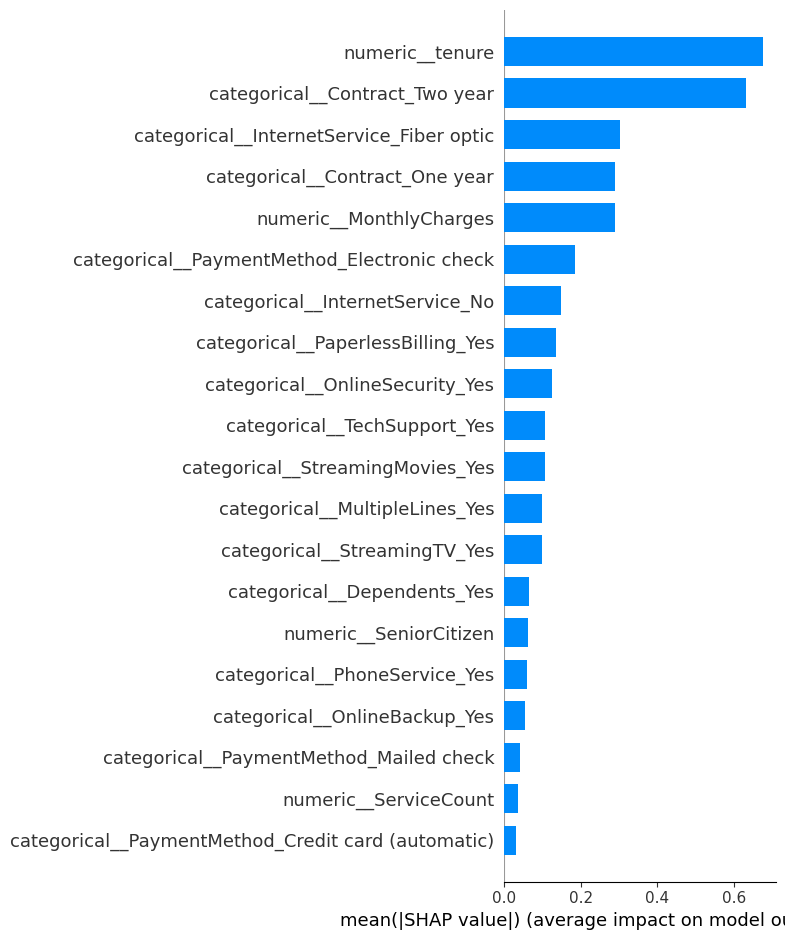

In [ ]:
#Bar version of the SHAP plot
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    plot_type="bar"
)

In [ ]:
##Step 7C: Individual Customer Explanations.
# Step 7C — Make XGBoost predictions

y_pred_xgb = xgb_model.predict(X_test_processed)

print("XGBoost predictions created.")
print("Number of predictions:", len(y_pred_xgb))
print("Number of test samples:", len(y_test))

XGBoost predictions created.
Number of predictions: 1409
Number of test samples: 1409


In [ ]:
#Find correctly predicted churners and retained customers
# Find correctly predicted churned customers
correct_churn = (y_test == 1) & (y_pred_xgb == 1)

# Find correctly predicted retained customers
correct_retained = (y_test == 0) & (y_pred_xgb == 0)

print("Correctly predicted churners:", correct_churn.sum())
print("Correctly predicted retained customers:", correct_retained.sum())

Correctly predicted churners: 292
Correctly predicted retained customers: 768


In [ ]:
#Convert test data into a DataFrame

X_test_shap = pd.DataFrame(
    X_test_processed,
    columns=feature_names
)

print("SHAP test data shape:", X_test_shap.shape)

SHAP test data shape: (1409, 33)


In [ ]:
# Reset indexes so everything lines up correctly
y_test_reset = pd.Series(y_test).reset_index(drop=True)
y_pred_xgb_reset = pd.Series(y_pred_xgb).reset_index(drop=True)

X_test_shap = X_test_shap.reset_index(drop=True)

In [ ]:
# Find correctly predicted customers

correct_churn = (y_test_reset == 1) & (y_pred_xgb_reset == 1)
correct_retained = (y_test_reset == 0) & (y_pred_xgb_reset == 0)

# Select the first correctly predicted churner
churn_idx = correct_churn[correct_churn].index[0]

# Select the first correctly predicted retained customer
retained_idx = correct_retained[correct_retained].index[0]

print("Selected churner index:", churn_idx)
print("Selected retained customer index:", retained_idx)

Selected churner index: 9
Selected retained customer index: 0


In [ ]:
#Check their actual predictions
print("Churn customer:")
print("Actual:", y_test_reset.iloc[churn_idx])
print("Predicted:", y_pred_xgb_reset.iloc[churn_idx])

print("\nRetained customer:")
print("Actual:", y_test_reset.iloc[retained_idx])
print("Predicted:", y_pred_xgb_reset.iloc[retained_idx])

Churn customer:
Actual: 1
Predicted: 1

Retained customer:
Actual: 0
Predicted: 0


In [ ]:
# SHAP values for the correctly predicted churner
churn_shap = shap_values[churn_idx]

# SHAP values for the correctly predicted retained customer
retained_shap = shap_values[retained_idx]

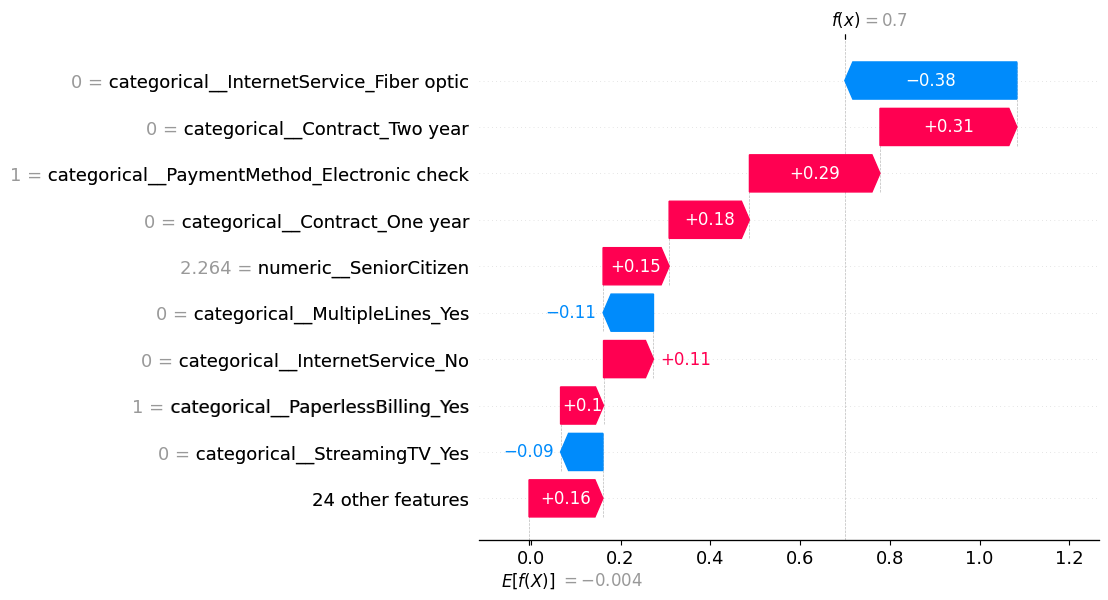

In [ ]:
#SHAP explanation for the churner
shap.waterfall_plot(
    shap.Explanation(
        values=churn_shap,
        base_values=explainer.expected_value,
        data=X_test_shap.iloc[churn_idx],
        feature_names=feature_names
    ),
    max_display=10
)

← Away from churn       Toward churn →

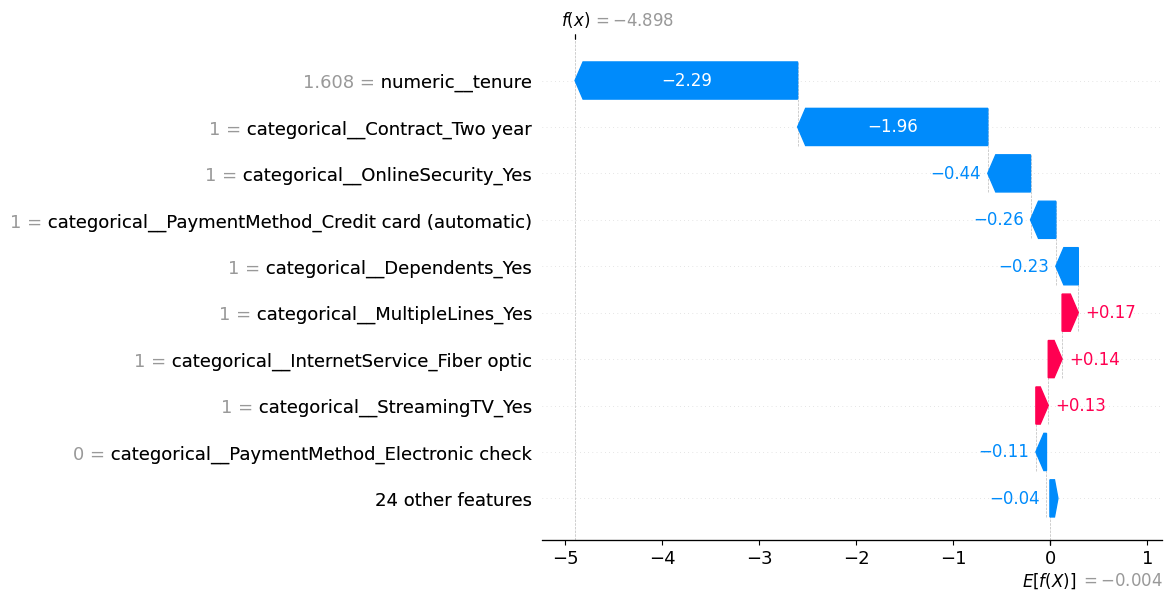

In [ ]:
#SHAP explanation for the retained customer
shap.waterfall_plot(
    shap.Explanation(
        values=retained_shap,
        base_values=explainer.expected_value,
        data=X_test_shap.iloc[retained_idx],
        feature_names=feature_names
    ),
    max_display=10
)

In [ ]:
#Also get their churn probabilities
# Churn probability for the selected churner
churn_probability = xgb_model.predict_proba(
    X_test_processed[churn_idx:churn_idx + 1]
)[0][1]

# Churn probability for the selected retained customer
retained_probability = xgb_model.predict_proba(
    X_test_processed[retained_idx:retained_idx + 1]
)[0][1]

print(f"Churner probability: {churn_probability:.2%}")
print(f"Retained customer probability: {retained_probability:.2%}")

Churner probability: 66.81%
Retained customer probability: 0.74%


Individual Customer — Correctly Predicted Retained: XGBoost correctly predicted that this customer would not churn. The SHAP explanation shows which customer characteristics pushed the prediction toward retention and which factors increased churn risk. This demonstrates that PulseIQ can provide not only a churn prediction but also an explanation of the factors influencing that predictio

In [ ]:
##Step 8 — Business Insights & Recommendations
#8A — Churn Rate by Contract
# Step 8A — Churn Rate by Contract

contract_churn = pd.crosstab(
    df_model["Contract"],
    df_model["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,0,1
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


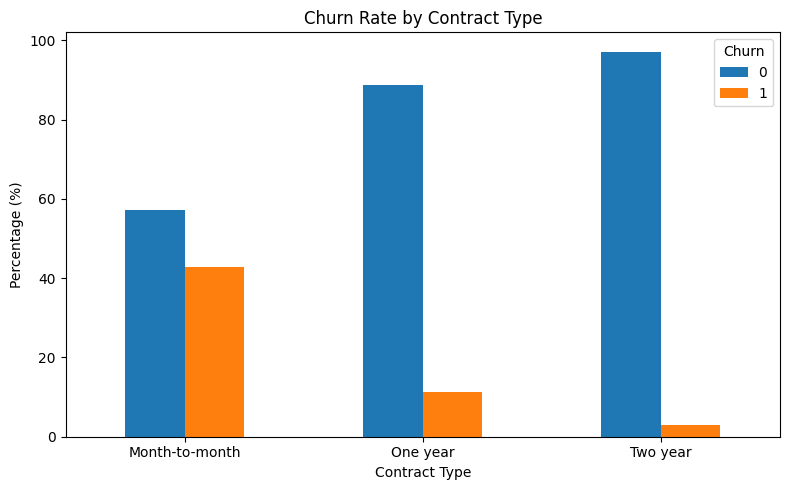

In [ ]:
#8B — Visualize Contract Churn
import matplotlib.pyplot as plt

contract_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

This helps the company see which contract group has the greatest churn risk.

For example, if month-to-month customers have substantially higher churn:

The company could target month-to-month customers with incentives to move to longer contracts.

In [ ]:
#8C — Churn Rate by Internet Service
# Churn rate by Internet Service

internet_churn = pd.crosstab(
    df_model["InternetService"],
    df_model["Churn"],
    normalize="index"
) * 100

internet_churn

Churn,0,1
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


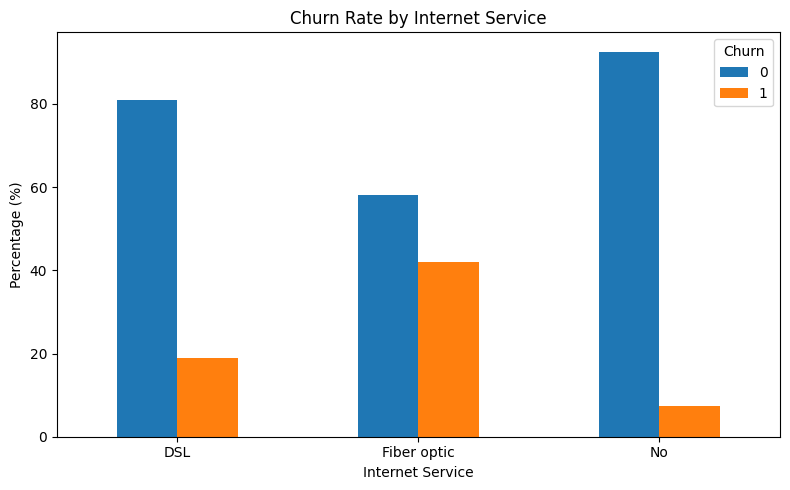

In [ ]:
internet_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

In [ ]:
#8D — Churn Rate by Payment Method
# Churn rate by payment method

payment_churn = pd.crosstab(
    df_model["PaymentMethod"],
    df_model["Churn"],
    normalize="index"
) * 100

payment_churn

Churn,0,1
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


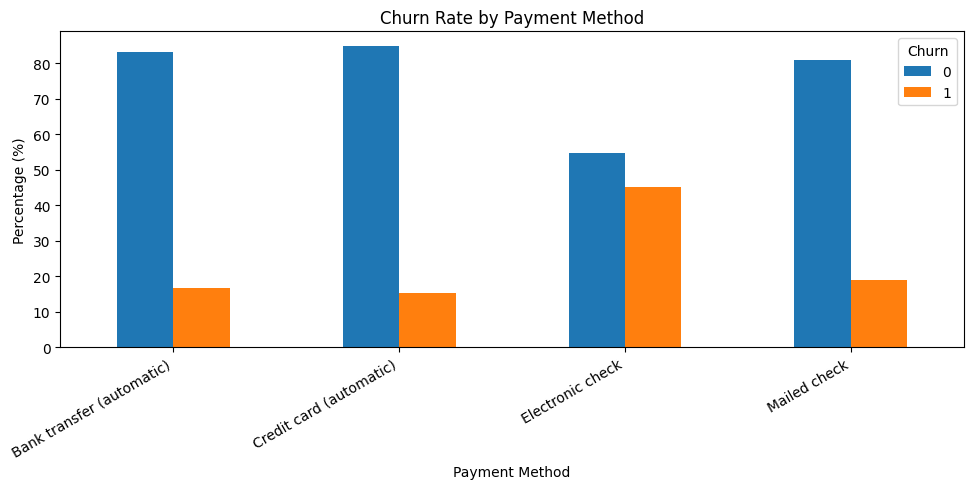

In [ ]:
payment_churn.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

In [ ]:
#8E — Churn Rate by Tech Support
# Churn rate by Tech Support

techsupport_churn = pd.crosstab(
    df_model["TechSupport"],
    df_model["Churn"],
    normalize="index"
) * 100

techsupport_churn

Churn,0,1
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


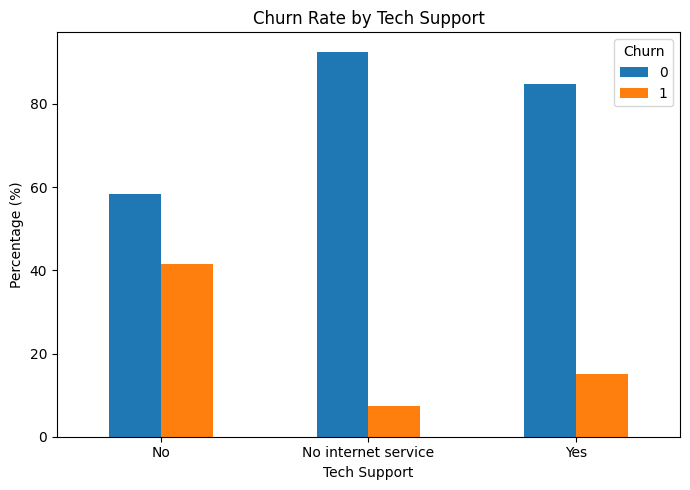

In [ ]:
techsupport_churn.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

In [ ]:
#8F — Churn Rate by Tenure Bucket
print("TenureBucket" in df_model.columns)

True


In [ ]:
tenure_churn = pd.crosstab(
    df_model["TenureBucket"],
    df_model["Churn"],
    normalize="index"
) * 100

tenure_churn

Churn,0,1
TenureBucket,,
0-12,52.561757,47.438243
13-24,71.289062,28.710938
25-48,79.611041,20.388959
49+,90.486824,9.513176


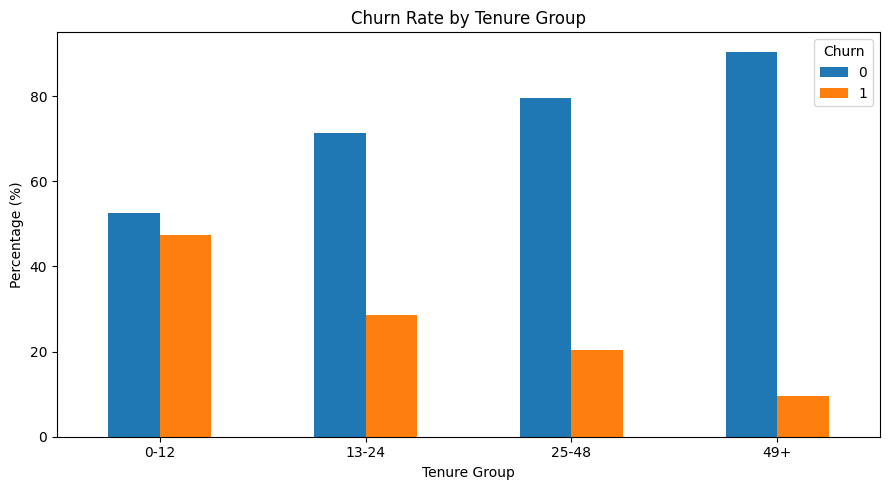

In [ ]:
tenure_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

In [ ]:
#8G — Create a High-Risk Customer List
#Get XGBoost probabilities
# Get probability of churn for every test customer

churn_probability = xgb_model.predict_proba(
    X_test_processed
)[:, 1]

print(churn_probability[:10])

[0.00740711 0.9423883  0.12246535 0.57769674 0.00609142 0.8278549
 0.7239111  0.35173854 0.04531488 0.66814107]


In [ ]:
#8H — Create Risk Levels
# Create risk categories

risk_level = pd.cut(
    churn_probability,
    bins=[0, 0.30, 0.60, 1.00],
    labels=["Low Risk", "Medium Risk", "High Risk"],
    include_lowest=True
)

risk_level.value_counts()

,count
Low Risk,656
Medium Risk,292
High Risk,461


In [ ]:
# Step 8I — Create High-Risk Customer Table

# Get the original test customers
risk_df = df.loc[X_test.index].copy()

# Reset index so customer rows align with prediction arrays
risk_df = risk_df.reset_index(drop=True)

# Add churn probability
risk_df["ChurnProbability"] = churn_probability

# Add risk level
risk_df["RiskLevel"] = risk_level.to_numpy()

# Add predicted churn
risk_df["PredictedChurn"] = (churn_probability >= 0.5).astype(int)

# Display first 5 customers
risk_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnProbability,RiskLevel,PredictedChurn
0,4376-KFVRS,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,...,Yes,Two year,Yes,Credit card (automatic),114.05,8468.20,No,0.007407,Low Risk,0
1,2754-SDJRD,Female,1,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55,No,0.942388,High Risk,1
2,9917-KWRBE,Female,0,Yes,Yes,41,Yes,Yes,DSL,Yes,...,No,One year,Yes,Credit card (automatic),78.35,3211.20,No,0.122465,Low Risk,0
3,0365-GXEZS,Male,0,Yes,No,18,Yes,No,Fiber optic,No,...,No,Month-to-month,No,Electronic check,78.20,1468.75,No,0.577697,Medium Risk,1
4,9385-NXKDA,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,...,Yes,Two year,Yes,Credit card (automatic),82.65,5919.35,No,0.006091,Low Risk,0


In [ ]:
# Step 8J — Show High-Risk Customers

high_risk_customers = risk_df[
    risk_df["RiskLevel"] == "High Risk"
].copy()

print("Number of high-risk customers:", len(high_risk_customers))

high_risk_customers.head(10)

Number of high-risk customers: 461


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnProbability,RiskLevel,PredictedChurn
1,2754-SDJRD,Female,1,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55,No,0.942388,High Risk,1
5,4686-UXDML,Female,0,No,No,21,Yes,Yes,Fiber optic,No,...,Yes,Month-to-month,Yes,Credit card (automatic),99.85,1992.55,No,0.827855,High Risk,1
6,2227-JRSJX,Female,0,No,No,21,Yes,No,Fiber optic,No,...,Yes,Month-to-month,Yes,Bank transfer (automatic),99.15,1956.40,No,0.723911,High Risk,1
9,4690-LLKUA,Male,1,No,No,17,Yes,No,DSL,No,...,No,Month-to-month,Yes,Electronic check,45.05,770.60,Yes,0.668141,High Risk,1
10,5804-HYIEZ,Male,0,Yes,Yes,70,Yes,Yes,Fiber optic,Yes,...,Yes,Month-to-month,Yes,Electronic check,106.05,7554.05,No,0.600538,High Risk,1
13,4706-AXVKM,Female,1,No,No,11,Yes,Yes,Fiber optic,No,...,Yes,Month-to-month,Yes,Credit card (automatic),84.80,906.85,Yes,0.843395,High Risk,1
17,1379-FRVEB,Male,0,No,Yes,15,Yes,Yes,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,91.00,1430.05,No,0.797929,High Risk,1
20,7235-NXZCP,Male,1,No,No,2,Yes,Yes,Fiber optic,No,...,No,Month-to-month,Yes,Mailed check,74.85,156.40,Yes,0.855565,High Risk,1
26,1894-IGFSG,Female,0,No,No,22,Yes,No,Fiber optic,No,...,Yes,Month-to-month,No,Electronic check,89.25,1907.85,Yes,0.640382,High Risk,1
27,0871-URUWO,Male,0,Yes,No,13,Yes,Yes,Fiber optic,No,...,Yes,Month-to-month,Yes,Credit card (automatic),102.25,1359.00,Yes,0.891169,High Risk,1


In [ ]:
# Sort highest churn probability first

high_risk_customers = high_risk_customers.sort_values(
    by="ChurnProbability",
    ascending=False
)

high_risk_customers.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnProbability,RiskLevel,PredictedChurn
1175,6861-XWTWQ,Male,1,Yes,No,7,Yes,Yes,Fiber optic,No,...,Yes,Month-to-month,Yes,Electronic check,99.25,665.45,Yes,0.972685,High Risk,1
1109,1069-XAIEM,Female,1,No,No,1,Yes,Yes,Fiber optic,No,...,Yes,Month-to-month,Yes,Electronic check,85.05,85.05,Yes,0.971565,High Risk,1
1221,0295-PPHDO,Male,0,No,No,1,Yes,Yes,Fiber optic,No,...,Yes,Month-to-month,Yes,Electronic check,95.45,95.45,Yes,0.969797,High Risk,1
1090,5178-LMXOP,Male,1,Yes,No,1,Yes,Yes,Fiber optic,No,...,Yes,Month-to-month,Yes,Electronic check,95.10,95.10,Yes,0.969543,High Risk,1
1188,0655-RBDUG,Male,0,No,No,7,Yes,Yes,Fiber optic,No,...,Yes,Month-to-month,Yes,Bank transfer (automatic),98.05,713.00,Yes,0.969078,High Risk,1
618,9248-OJYKK,Male,1,No,No,1,Yes,Yes,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,76.45,76.45,Yes,0.963209,High Risk,1
1259,2609-IAICY,Female,0,No,No,1,Yes,Yes,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,77.15,77.15,Yes,0.959354,High Risk,1
83,0970-ETWGE,Male,0,No,No,1,Yes,No,Fiber optic,No,...,Yes,Month-to-month,Yes,Electronic check,89.55,89.55,Yes,0.957639,High Risk,1
344,6230-BSUXY,Female,1,No,No,1,Yes,No,Fiber optic,No,...,Yes,Month-to-month,Yes,Electronic check,85.00,85.00,Yes,0.957349,High Risk,1
627,9057-SIHCH,Female,0,No,No,3,Yes,Yes,Fiber optic,No,...,Yes,Month-to-month,Yes,Electronic check,96.60,291.90,Yes,0.953928,High Risk,1


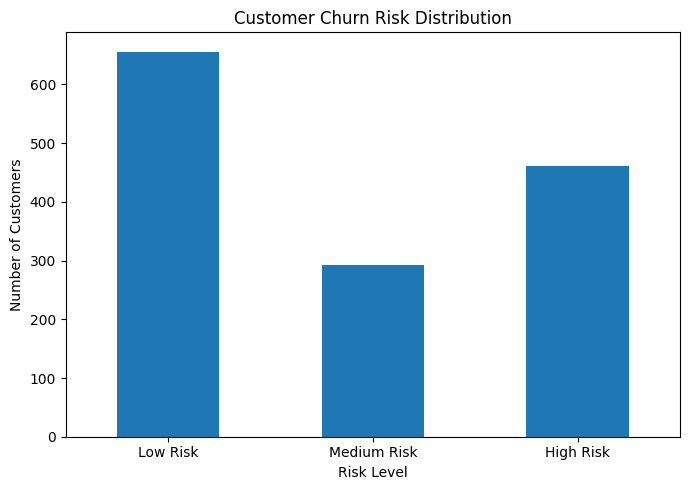

In [ ]:
#8L — Create a Simple Risk Distribution Chart
risk_counts = risk_level.value_counts()

risk_counts.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Customer Churn Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
#8M — Add Recommended Actions
risk_actions = {
    "Low Risk": "Normal customer engagement",
    "Medium Risk": "Monitor customer and consider targeted offer",
    "High Risk": "Immediate retention action"
}

risk_df["RecommendedAction"] = risk_df["RiskLevel"].map(risk_actions)

risk_df[
    ["ChurnProbability", "RiskLevel", "RecommendedAction"]
].head(10)

,ChurnProbability,RiskLevel,RecommendedAction
0,0.007407,Low Risk,Normal customer engagement
1,0.942388,High Risk,Immediate retention action
2,0.122465,Low Risk,Normal customer engagement
3,0.577697,Medium Risk,Monitor customer and consider targeted offer
4,0.006091,Low Risk,Normal customer engagement
5,0.827855,High Risk,Immediate retention action
6,0.723911,High Risk,Immediate retention action
7,0.351739,Medium Risk,Monitor customer and consider targeted offer
8,0.045315,Low Risk,Normal customer engagement
9,0.668141,High Risk,Immediate retention action


In [ ]:
#8N — Final Business Insight Table
business_summary = pd.DataFrame({
    "Business Factor": [
        "Contract Type",
        "Internet Service",
        "Payment Method",
        "Tech Support",
        "Customer Tenure"
    ],
    "Why It Matters": [
        "Different contract groups show different churn rates",
        "Churn varies across internet service types",
        "Some payment methods are associated with higher churn",
        "Support availability may influence retention",
        "Newer customers tend to have higher churn risk"
    ],
    "Recommended Action": [
        "Encourage high-risk customers to move to longer contracts",
        "Investigate service quality and customer experience",
        "Investigate payment experience and encourage reliable payment options",
        "Offer proactive technical support to at-risk customers",
        "Create stronger onboarding and early-retention programs"
    ]
})

business_summary

,Business Factor,Why It Matters,Recommended Action
0,Contract Type,Different contract groups show different churn...,Encourage high-risk customers to move to longe...
1,Internet Service,Churn varies across internet service types,Investigate service quality and customer exper...
2,Payment Method,Some payment methods are associated with highe...,Investigate payment experience and encourage r...
3,Tech Support,Support availability may influence retention,Offer proactive technical support to at-risk c...
4,Customer Tenure,Newer customers tend to have higher churn risk,Create stronger onboarding and early-retention...


In [ ]:
# 1. Save the XGBoost model natively (JSON format)
xgb_model.save_model("xgboost_model.json")
print("XGBoost model saved successfully!")

XGBoost model saved successfully!


In [ ]:
import joblib
joblib.dump(preprocessor, "preprocessor.pkl")
print("Preprocessor saved successfully!")

Preprocessor saved successfully!
